# HIT Lagrangian particle calculation with moving-time-block bootstrap

Run the setup cells first, then run N=200, 2,000, and 5,000 in separate cells. The separation scales and MBB output schema match the Eulerian calculation.


In [41]:
import sys
import importlib
import inspect
from pathlib import Path
import numpy as np

code_dir = Path("/meddy/simingzhang/Analysis/python/python3")
if str(code_dir) not in sys.path:
    sys.path.insert(0, str(code_dir))

import third_order_diagnostics as tod
import gridblock_jupyter as gb
import hit_particle_mbb as hpmbb
importlib.invalidate_caches()
tod = importlib.reload(tod)
gb = importlib.reload(gb)
hpmbb = importlib.reload(hpmbb)

print("module:", hpmbb.__file__)
print("runner:", inspect.signature(hpmbb.run_hit_eulerian_scales))


module: /meddy/simingzhang/Analysis/python/python3/hit_particle_mbb.py
runner: (cfg)


In [42]:
# Common scales and configuration
dx_hit = 2.0 * np.pi / 512.0
r_requested_hit = np.geomspace(2.0 * dx_hit, np.pi, 12)

base_cfg = dict(
    input_dir=Path("/meddy/simingzhang/Data/Parcels_data/HIT2d_rough"),
    nparticles_file=62500,
    seconds=20.0,
    dt=0.1,
    timerange_matlab=np.arange(50, 151),
    period=2.0 * np.pi,
    nblock_x=4,
    nblock_y=4,
    min_pairs=1,
    min_valid_blocks=8,
    random_seed=1,
    r_requested=r_requested_hit,
    third_pdf_reservoir_size=100_000,
    do_moving_block_bootstrap=True,
    mbb_num_boot=1000,
    mbb_confidence=0.95,
    mbb_block_length_time=None,
    mbb_random_seed=271828,
)

print("requested scales:", r_requested_hit)
print("number of times:", len(base_cfg["timerange_matlab"]))


requested scales: [0.02454369 0.05509873 0.12369246 0.27768018 0.62337094 1.39942043
 3.14159265]
number of times: 101


In [26]:
# N = 200
cfg_200 = dict(base_cfg)
cfg_200.update(
    num_to_select=200,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P200T150_EulerianScalesHL_MBB.mat",
)
result_200, output_200 = hpmbb.run_hit_eulerian_scales(cfg_200)
print("Saved:", output_200)

# # N = 200
# cfg_200 = dict(base_cfg)
# cfg_200.update(
#     num_to_select=200,
#     output_path=base_cfg["input_dir"] / "HIT2d_pars_P200T150_EulerianScalesHL1.mat",
# )
# result_200, output_200 = hpmbb.run_hit_eulerian_scales(cfg_200)
# print("Saved:", output_200)

Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|████████████████████████| 101/101 [00:01<00:00, 60.19time/s]



Finished.
Runtime: 0.03 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P200T150_EulerianScalesHL1.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P200T150_EulerianScalesHL1.mat


In [4]:
# N = 2,000
cfg_2000 = dict(base_cfg)
cfg_2000.update(
    num_to_select=2000,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P2000T150_EulerianScalesHL_MBB.mat",
)
result_2000, output_2000 = hpmbb.run_hit_eulerian_scales(cfg_2000)
print("Saved:", output_2000)


Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|████████████████████████| 101/101 [02:49<00:00,  1.68s/time]



Finished.
Runtime: 2.83 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P2000T150_EulerianScalesHL_MBB.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P2000T150_EulerianScalesHL_MBB.mat


In [5]:
# N = 5,000
cfg_5000 = dict(base_cfg)
cfg_5000.update(
    num_to_select=5000,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P5000T150_EulerianScalesHL_MBB.mat",
)
result_5000, output_5000 = hpmbb.run_hit_eulerian_scales(cfg_5000)
print("Saved:", output_5000)


Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|████████████████████████| 101/101 [18:54<00:00, 11.24s/time]



Finished.
Runtime: 18.92 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P5000T150_EulerianScalesHL_MBB.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P5000T150_EulerianScalesHL_MBB.mat


In [36]:
cfg_10000 = dict(base_cfg)
cfg_10000.update(
    num_to_select=10000,
    output_path=base_cfg["input_dir"] / "HIT2d_pars_P10000T150_EulerianScalesHL_MBB.mat",
)
result_10000, output_10000 = hpmbb.run_hit_eulerian_scales(cfg_10000)
print("Saved:", output_10000)

Opening:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P62500T20.0seconds.nc


HIT Lagrangian pair statistics: 100%|██████████████████████| 101/101 [1:25:19<00:00, 50.69s/time]



Finished.
Runtime: 85.34 min
Saved:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P10000T150_EulerianScalesHL_MBB.mat
Saved: /meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P10000T150_EulerianScalesHL_MBB.mat


# plot

In [37]:
particle_dir = Path(
    "/meddy/simingzhang/Data/"
    "Parcels_data/HIT2d_rough"
)

eulerian_dir = Path(
    "/meddy/simingzhang/Data/HIT2D/2dt2"
)


result_paths = {
    "result_200": (
        particle_dir
        / "HIT2d_pars_P200T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_2000": (
        particle_dir
        / "HIT2d_pars_P2000T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_5000": (
        particle_dir
        / "HIT2d_pars_P5000T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_10000": (
        particle_dir
        / "HIT2d_pars_P10000T150_"
          "EulerianScalesHL_MBB.mat"
    ),

    "result_eulerian": (
        eulerian_dir
        / "HIT_Eulerian_r2dx_to_pi_"
          "12scales_t50_150.mat"
    ),
}


def load_result(path):

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"File not found:\n{path}"
        )

    data = sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
    )

    return {
        key: value
        for key, value in data.items()
        if not key.startswith("__")
    }


for variable_name, path in result_paths.items():

    if variable_name not in globals():

        globals()[variable_name] = (
            load_result(path)
        )

        print(
            f"Loaded {variable_name}:\n"
            f"{path}"
        )

In [38]:
cases = [
    (
        result_200,
        "N = 200",
        "#0072B2",
        "-",
    ),
    (
        result_2000,
        "N = 2,000",
        "#D55E00",
        "-",
    ),
    (
        result_5000,
        "N = 5,000",
        "#009E73",
        "-",
    ),
    (
        result_10000,
        "N = 10,000",
        "#CC79A7",
        "-",
    ),
    (
        result_eulerian,
        "Eulerian",
        "#000000",
        "--",
    ),
]

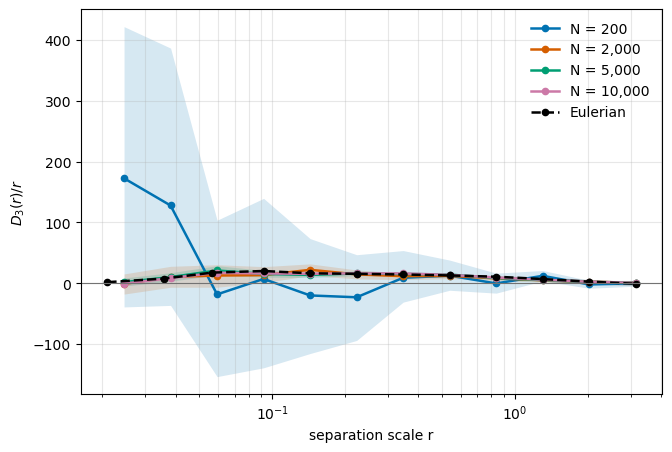

In [39]:
fig, ax = plt.subplots(
    figsize=(7.5, 5.0)
)


for result, label, color, linestyle in cases:

    r = np.asarray(
        result["dist_axis"],
        dtype=float,
    ).squeeze()

    D3 = np.asarray(
        result["D3"],
        dtype=float,
    ).squeeze()

    ci_low = np.asarray(
        result["D3_mbb_ci_low"],
        dtype=float,
    ).squeeze()

    ci_high = np.asarray(
        result["D3_mbb_ci_high"],
        dtype=float,
    ).squeeze()

    order = np.argsort(r)

    r = np.ravel(r)[order]
    D3 = np.ravel(D3)[order]
    ci_low = np.ravel(ci_low)[order]
    ci_high = np.ravel(ci_high)[order]

    D3_over_r = np.divide(
        D3,
        r,
        out=np.full_like(D3, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0)
        ),
    )

    ci_low_over_r = np.divide(
        ci_low,
        r,
        out=np.full_like(ci_low, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0)
        ),
    )

    ci_high_over_r = np.divide(
        ci_high,
        r,
        out=np.full_like(ci_high, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0)
        ),
    )

    valid_line = (
        np.isfinite(r)
        & (r > 0)
        & np.isfinite(D3_over_r)
    )

    valid_ci = (
        valid_line
        & np.isfinite(ci_low_over_r)
        & np.isfinite(ci_high_over_r)
    )

    ax.fill_between(
        r[valid_ci],
        ci_low_over_r[valid_ci],
        ci_high_over_r[valid_ci],
        color=color,
        alpha=0.16,
        linewidth=0,
    )

    ax.semilogx(
        r[valid_line],
        D3_over_r[valid_line],
        marker="o",
        markersize=4.5,
        color=color,
        linestyle=linestyle,
        linewidth=1.8,
        label=label,
    )


ax.axhline(
    0.0,
    color="0.45",
    linewidth=0.8,
)

ax.set_xlabel(
    "separation scale r"
)

ax.set_ylabel(
    r"$D_3(r)/r$"
)

ax.grid(
    True,
    which="both",
    alpha=0.3,
)

ax.legend(
    frameon=False,
)

plt.show()

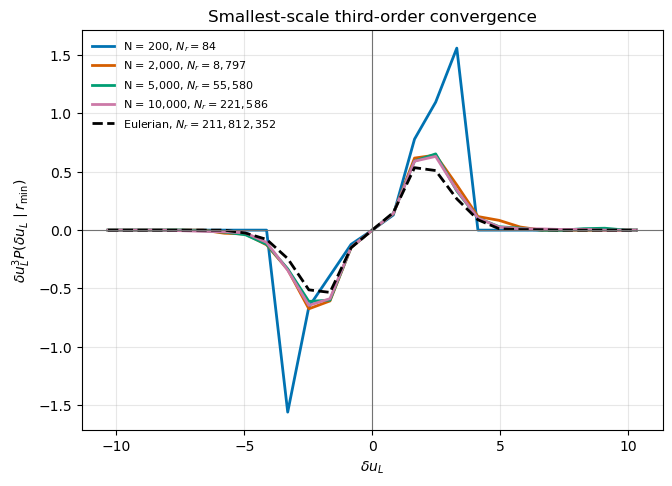

In [40]:
# ============================================================
# Smallest-scale signed D_LLL contribution
# ============================================================

number_of_bins = 25

smallest_scale_data = []


for result, label, color, linestyle in cases:

    r = np.asarray(
        result["dist_axis"],
        dtype=float,
    ).squeeze()

    count = np.asarray(
        result["count_total"],
        dtype=float,
    ).squeeze()

    reservoir = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    r = np.ravel(r)
    count = np.ravel(count)

    if reservoir.ndim == 1:
        reservoir = reservoir[
            None,
            :
        ]

    valid_scale_indices = np.flatnonzero(
        np.isfinite(r)
        & (r > 0)
    )

    if valid_scale_indices.size == 0:
        raise RuntimeError(
            f"{label}: no valid scale."
        )

    scale_index = (
        valid_scale_indices[
            np.argmin(
                r[valid_scale_indices]
            )
        ]
    )

    sample = reservoir[
        scale_index
    ]

    sample = sample[
        np.isfinite(sample)
    ]

    if sample.size == 0:
        raise RuntimeError(
            f"{label}: no smallest-scale "
            "reservoir samples."
        )

    smallest_scale_data.append(
        {
            "label": label,
            "color": color,
            "linestyle": linestyle,
            "r": r[scale_index],
            "sample": sample,
            "count": count[scale_index],
        }
    )


# Common full range
all_samples = np.concatenate(
    [
        item["sample"]
        for item in smallest_scale_data
    ]
)

du_limit = (
    1.10
    * np.nanmax(
        np.abs(all_samples)
    )
)

bin_edges = np.linspace(
    -du_limit,
    du_limit,
    number_of_bins + 1,
)

bin_centers = 0.5 * (
    bin_edges[:-1]
    + bin_edges[1:]
)

bin_widths = np.diff(
    bin_edges
)


fig, ax = plt.subplots(
    figsize=(7.5, 5.2)
)


for item in smallest_scale_data:

    counts, _ = np.histogram(
        item["sample"],
        bins=bin_edges,
    )

    pdf = np.divide(
        counts,
        (
            item["sample"].size
            * bin_widths
        ),
        out=np.zeros(
            number_of_bins,
            dtype=float,
        ),
        where=bin_widths > 0,
    )

    signed_contribution = (
        bin_centers**3
        * pdf
    )

    # Add zero endpoints
    plot_x = np.concatenate(
        (
            [bin_edges[0]],
            bin_centers,
            [bin_edges[-1]],
        )
    )

    plot_y = np.concatenate(
        (
            [0.0],
            signed_contribution,
            [0.0],
        )
    )

    ax.plot(
        plot_x,
        plot_y,
        color=item["color"],
        linestyle=item["linestyle"],
        linewidth=2.0,
        label=(
            f"{item['label']}, "
            f"$N_r={int(item['count']):,}$"
        ),
    )


ax.axhline(
    0.0,
    color="0.45",
    linewidth=0.8,
)

ax.axvline(
    0.0,
    color="0.45",
    linewidth=0.8,
)

ax.set_xlabel(
    r"$\delta u_L$"
)

ax.set_ylabel(
    r"$\delta u_L^3"
    r"P(\delta u_L\mid r_{\min})$"
)

ax.set_title(
    "Smallest-scale third-order convergence"
)

ax.grid(
    True,
    alpha=0.3,
)

ax.legend(
    frameon=False,
    fontsize=8,
)

plt.show()

# plot without MBB

In [43]:
# ============================================================
# Read saved non-MBB results
# ============================================================

from pathlib import Path
import numpy as np
import scipy.io as sio


# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

particle_dir = Path(
    "/meddy/simingzhang/Data/"
    "Parcels_data/HIT2d_rough"
)

eulerian_dir = Path(
    "/meddy/simingzhang/Data/HIT2D/2dt2"
)


# ------------------------------------------------------------
# Saved file paths
# ------------------------------------------------------------

path_200 = (
    particle_dir
    / "HIT2d_pars_P200T150_EulerianScalesHL.mat"
)

path_2000 = (
    particle_dir
    / "HIT2d_pars_P2000T150_EulerianScalesHL.mat"
)

path_5000 = (
    particle_dir
    / "HIT2d_pars_P5000T150_EulerianScalesHL.mat"
)

path_eulerian = (
    eulerian_dir
    / "HIT_Eulerian_matching_particle_cases.mat"
)


# ------------------------------------------------------------
# Loader
# ------------------------------------------------------------

def load_saved_result(path):

    path = Path(path)

    if not path.exists():

        raise FileNotFoundError(
            f"Saved result was not found:\n{path}"
        )

    data = sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
    )

    result = {
        key: value
        for key, value in data.items()
        if not key.startswith("__")
    }

    print(
        f"Loaded:\n{path}"
    )

    return result


# ------------------------------------------------------------
# Load four results
# ------------------------------------------------------------

result_200 = load_saved_result(
    path_200
)

result_2000 = load_saved_result(
    path_2000
)

result_5000 = load_saved_result(
    path_5000
)

result_eulerian = load_saved_result(
    path_eulerian
)


print("\nAll saved results loaded.")

Loaded:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P200T150_EulerianScalesHL.mat
Loaded:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P2000T150_EulerianScalesHL.mat
Loaded:
/meddy/simingzhang/Data/Parcels_data/HIT2d_rough/HIT2d_pars_P5000T150_EulerianScalesHL.mat
Loaded:
/meddy/simingzhang/Data/HIT2D/2dt2/HIT_Eulerian_matching_particle_cases.mat

All saved results loaded.


In [44]:
# ============================================================
# Plot D3(r)/r
# Three Lagrangian cases + one Eulerian case
# ============================================================

import numpy as np
import matplotlib.pyplot as plt


cases = [
    (
        result_200,
        "Lagrangian\nN = 200",
        "#0072B2",
        "-",
    ),
    (
        result_2000,
        "Lagrangian\nN = 2,000",
        "#D55E00",
        "-",
    ),
    (
        result_5000,
        "Lagrangian\nN = 5,000",
        "#009E73",
        "-",
    ),
    (
        result_eulerian,
        "Eulerian",
        "black",
        "--",
    ),
]


def read_vector(result, names, label):

    for name in names:

        if name in result:

            return np.asarray(
                result[name],
                dtype=float,
            ).squeeze().ravel()

    raise KeyError(
        f"{label}: none of {names} found.\n"
        f"Available keys:\n{sorted(result.keys())}"
    )


plot_data = []


for result, label, color, linestyle in cases:

    r = read_vector(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
        ],
        f"{label} separation",
    )

    # Most saved files contain D3 directly.
    if "D3" in result:

        D3 = read_vector(
            result,
            ["D3"],
            f"{label} D3",
        )

    elif "SF3" in result:

        D3 = read_vector(
            result,
            ["SF3"],
            f"{label} SF3",
        )

    elif "mean_D3" in result:

        D3 = read_vector(
            result,
            ["mean_D3"],
            f"{label} mean_D3",
        )

    elif (
        "Dlll" in result
        and "Dltt" in result
    ):

        D3 = (
            read_vector(
                result,
                ["Dlll"],
                f"{label} Dlll",
            )
            + read_vector(
                result,
                ["Dltt"],
                f"{label} Dltt",
            )
        )

    elif (
        "SF3lll" in result
        and "SF3ltt" in result
    ):

        D3 = (
            read_vector(
                result,
                ["SF3lll"],
                f"{label} SF3lll",
            )
            + read_vector(
                result,
                ["SF3ltt"],
                f"{label} SF3ltt",
            )
        )

    else:

        raise KeyError(
            f"{label}: no D3-like field found."
        )

    if len(r) != len(D3):

        raise ValueError(
            f"{label}: len(r)={len(r)}, "
            f"len(D3)={len(D3)}"
        )

    order = np.argsort(r)

    r = r[order]
    D3 = D3[order]

    D3_over_r = np.divide(
        D3,
        r,
        out=np.full_like(D3, np.nan),
        where=(
            np.isfinite(r)
            & (r > 0.0)
            & np.isfinite(D3)
        ),
    )

    valid = (
        np.isfinite(r)
        & (r > 0.0)
        & np.isfinite(D3_over_r)
    )

    if not np.any(valid):

        raise RuntimeError(
            f"{label}: no finite D3/r values."
        )

    plot_data.append(
        {
            "label": label,
            "color": color,
            "linestyle": linestyle,
            "r": r[valid],
            "D3_over_r": D3_over_r[valid],
        }
    )

    print(
        f"{label}: {np.count_nonzero(valid)} valid scales"
    )

Lagrangian
N = 200: 11 valid scales
Lagrangian
N = 2,000: 11 valid scales
Lagrangian
N = 5,000: 11 valid scales
Eulerian: 12 valid scales


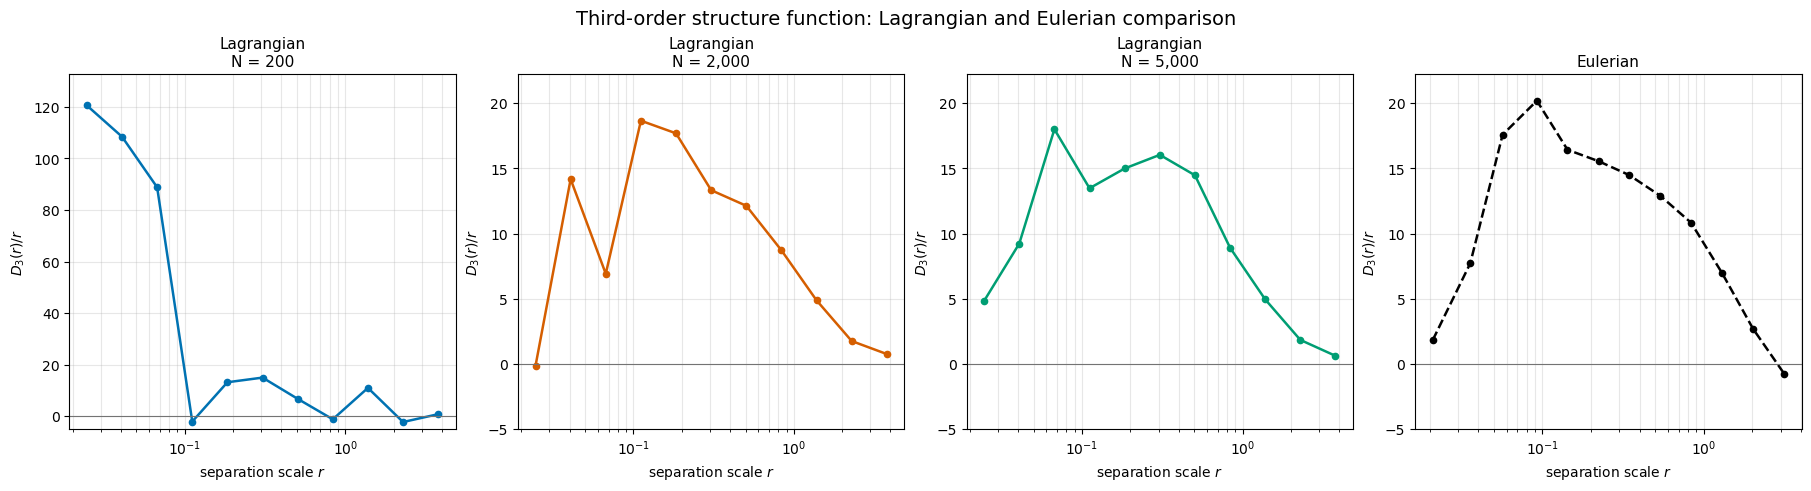

In [45]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. 需要已经在前面读取好的结果
# ============================================================

cases = [
    (
        result_200,
        "Lagrangian\nN = 200",
        "#0072B2",
        "-",
    ),
    (
        result_2000,
        "Lagrangian\nN = 2,000",
        "#D55E00",
        "-",
    ),
    (
        result_5000,
        "Lagrangian\nN = 5,000",
        "#009E73",
        "-",
    ),
    (
        result_eulerian,
        "Eulerian",
        "black",
        "--",
    ),
]


# ============================================================
# 2. 从 result 中读取一维数组
# ============================================================

def get_array(result, names):
    """
    按照 names 中的候选字段名读取数据。
    """
    for name in names:
        if name in result:
            value = np.asarray(result[name], dtype=float).squeeze()
            return np.ravel(value)

    raise KeyError(
        f"None of these fields were found: {names}\n"
        f"Available fields:\n{list(result.keys())}"
    )


def get_r(result):
    return get_array(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
            "r",
            "separation",
        ],
    )


def get_D3(result):
    """
    兼容不同版本保存的第三阶结构函数字段。
    """

    # 直接保存的 D3
    for name in ["D3", "SF3", "mean_D3"]:
        if name in result:
            return get_array(result, [name])

    # 如果保存的是纵向和横向分量，则重构
    if "Dlll" in result and "Dltt" in result:
        return (
            get_array(result, ["Dlll"])
            + get_array(result, ["Dltt"])
        )

    if "SF3lll" in result and "SF3ltt" in result:
        return (
            get_array(result, ["SF3lll"])
            + get_array(result, ["SF3ltt"])
        )

    raise KeyError(
        "Cannot find a third-order structure-function field."
    )


# ============================================================
# 3. 准备每个 case 的 r、D3 和 D3/r
# ============================================================

plot_data = []

for result, label, color, linestyle in cases:

    r = get_r(result)
    D3 = get_D3(result)

    n = min(r.size, D3.size)

    r = r[:n]
    D3 = D3[:n]

    D3_over_r = np.divide(
        D3,
        r,
        out=np.full_like(D3, np.nan, dtype=float),
        where=np.isfinite(r) & (r > 0),
    )

    valid = (
        np.isfinite(r)
        & (r > 0)
        & np.isfinite(D3_over_r)
    )

    order = np.argsort(r[valid])

    plot_data.append(
        {
            "r": r[valid][order],
            "D3": D3[valid][order],
            "D3_over_r": D3_over_r[valid][order],
            "label": label,
            "color": color,
            "linestyle": linestyle,
        }
    )


# ============================================================
# 4. 计算前三个 Lagrangian case 的共同 y 轴范围
#
#    第一个图可以单独缩放；
#    后三个图使用同一个 ylim。
# ============================================================

all_values_for_common_ylim = []

for item in plot_data[1:]:
    values = item["D3_over_r"]

    values = values[
        np.isfinite(values)
    ]

    if values.size > 0:
        all_values_for_common_ylim.append(values)


if len(all_values_for_common_ylim) == 0:
    raise RuntimeError(
        "No valid D3/r values were found for common ylim."
    )


all_values_for_common_ylim = np.concatenate(
    all_values_for_common_ylim
)

common_abs = np.nanmax(
    np.abs(all_values_for_common_ylim)
)

if not np.isfinite(common_abs) or common_abs == 0:
    common_abs = 1.0

common_abs *= 1.10

common_ylim = (
    -5,
    common_abs,
)


# ============================================================
# 5. 第一幅图使用自己的范围
# ============================================================

first_values = plot_data[0]["D3_over_r"]

first_values = first_values[
    np.isfinite(first_values)
]

if first_values.size == 0:
    first_abs = common_abs
else:
    first_abs = np.nanmax(
        np.abs(first_values)
    )

if not np.isfinite(first_abs) or first_abs == 0:
    first_abs = common_abs

first_abs *= 1.10


# ============================================================
# 6. 画图
# ============================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=4,
    figsize=(18, 4.8),
    constrained_layout=True,
    sharex=False,
)


for i, item in enumerate(plot_data):

    ax = axes[i]

    r = item["r"]
    D3_over_r = item["D3_over_r"]

    # 不使用 "o-"，避免和 linestyle 重复定义
    ax.semilogx(
        r,
        D3_over_r,
        marker="o",
        markersize=4.5,
        color=item["color"],
        linestyle=item["linestyle"],
        linewidth=1.8,
        label=item["label"],
    )

    ax.axhline(
        0.0,
        color="0.45",
        linewidth=0.8,
    )

    ax.set_xlabel(
        "separation scale $r$"
    )

    ax.set_ylabel(
        r"$D_3(r)/r$"
    )

    ax.set_title(
        item["label"],
        fontsize=11,
    )

    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    if i == 0:
        ax.set_ylim(
            -5,
            first_abs,
        )
    else:
        ax.set_ylim(
            common_ylim
        )
    # ax.set_ylim(common_ylim)


fig.suptitle(
    "Third-order structure function: "
    "Lagrangian and Eulerian comparison",
    fontsize=14,
)

output_png='/meddy/simingzhang/Data/SF_directly/SF3_hit.png'
fig.savefig(output_png,
    dpi=500,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

PDF scale indices: [0, 10]

PDF index = 0
Lagrangian
N = 200 r = 0.02454369260617026
Lagrangian
N = 2,000 r = 0.02454369260617026
Lagrangian
N = 5,000 r = 0.02454369260617026
Eulerian r = 0.020949352041675688

PDF index = 10
Lagrangian
N = 200 r = 3.7953249234203854
Lagrangian
N = 2,000 r = 3.7953249234203854
Lagrangian
N = 5,000 r = 3.7953249234203854
Eulerian r = 2.019017985681028


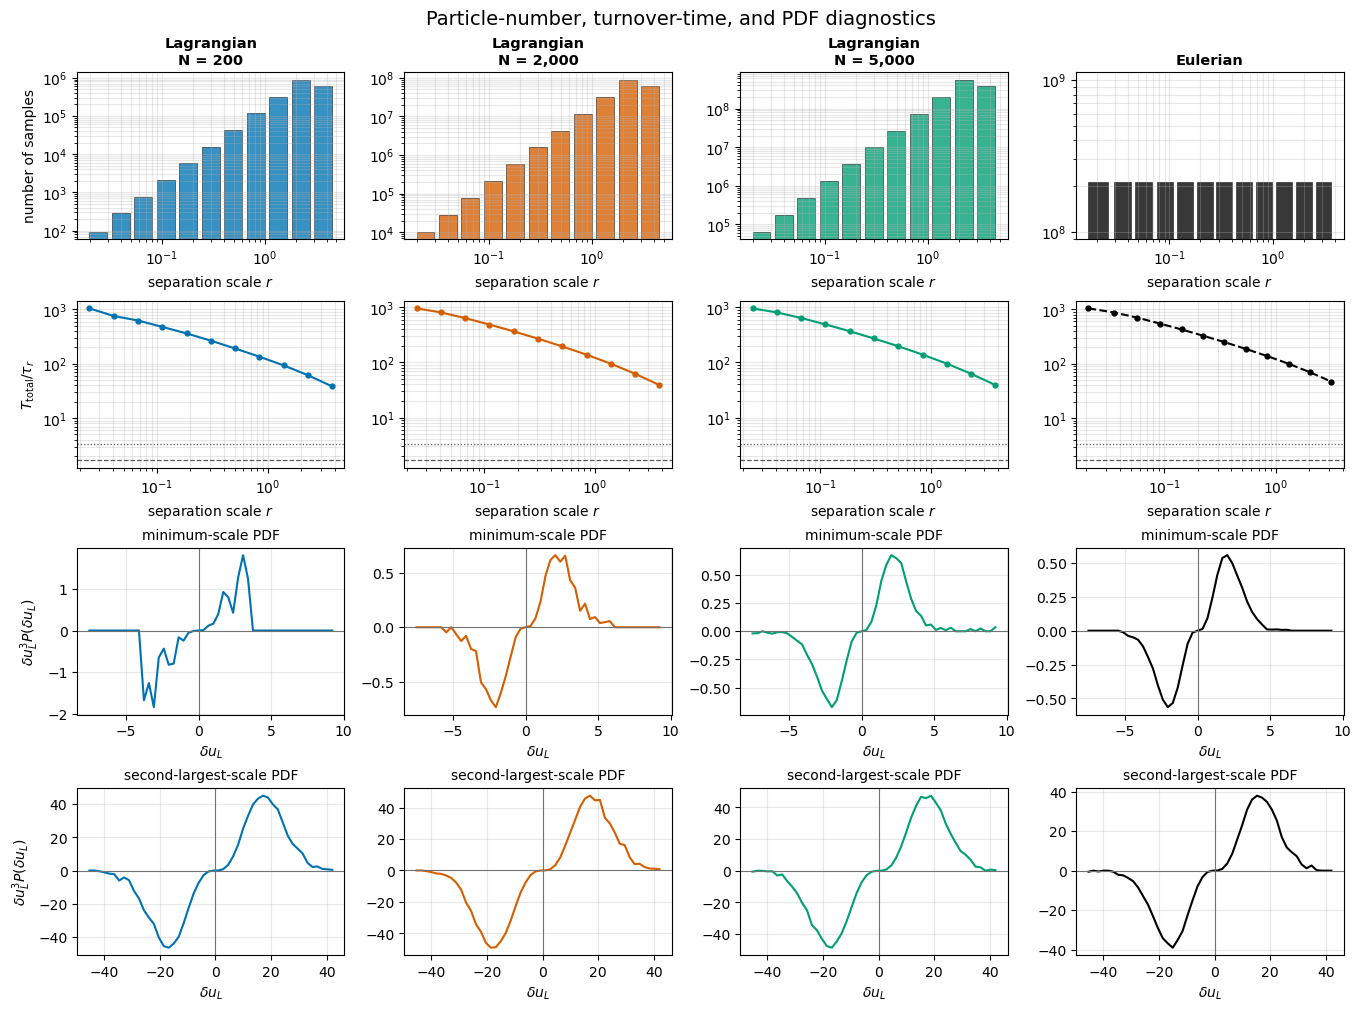

In [48]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. Cases
# ============================================================

cases = [
    (
        result_200,
        "Lagrangian\nN = 200",
        "#0072B2",
        "-",
        "lagrangian",
    ),
    (
        result_2000,
        "Lagrangian\nN = 2,000",
        "#D55E00",
        "-",
        "lagrangian",
    ),
    (
        result_5000,
        "Lagrangian\nN = 5,000",
        "#009E73",
        "-",
        "lagrangian",
    ),
    (
        result_eulerian,
        "Eulerian",
        "black",
        "--",
        "eulerian",
    ),
]


# ============================================================
# 2. Field readers
# ============================================================

def read_array(result, names, required=True):

    for name in names:

        if name in result:

            value = np.asarray(
                result[name],
                dtype=float,
            ).squeeze()

            return np.ravel(value)

    if required:
        raise KeyError(
            f"Cannot find fields {names}\n"
            f"Available fields:\n{list(result.keys())}"
        )

    return None


def read_r(result):

    return read_array(
        result,
        [
            "dist_axis",
            "r_actual",
            "r_requested",
            "r",
            "separation",
        ],
    )


def read_sf2(result):

    value = read_array(
        result,
        [
            "SF2",
            "sf2",
            "D2",
            "mean_D2",
        ],
        required=False,
    )

    if value is not None:
        return value

    dll = read_array(
        result,
        [
            "Dll",
            "D2ll",
            "SF2ll",
        ],
        required=False,
    )

    dtt = read_array(
        result,
        [
            "Dltt",
            "D2tt",
            "SF2tt",
        ],
        required=False,
    )

    if dll is not None and dtt is not None:
        return dll + dtt

    raise KeyError(
        "Cannot find SF2 or its components."
    )


def read_nsample(result, case_type):

    if case_type == "eulerian":

        sample_count = np.asarray(
            result["sample_count"],
            dtype=float,
        )

        if sample_count.ndim == 1:
            return sample_count

        # Eulerian sample_count shape: (nscale, nblock)
        return np.nansum(
            sample_count,
            axis=1,
        )

    for name in [
        "third_count",
        "dl_reservoir_count",
        "nsample",
        "n_samples",
        "sample_count",
        "pair_count",
    ]:

        if name in result:

            return np.asarray(
                result[name],
                dtype=float,
            ).ravel()

    return None


def read_reservoir(result):

    if "dl_reservoir" not in result:
        return None

    raw = np.asarray(
        result["dl_reservoir"],
        dtype=float,
    )

    if raw.ndim == 1:
        raw = raw[None, :]

    if "dl_reservoir_count" in result:

        count = np.asarray(
            result["dl_reservoir_count"],
            dtype=int,
        ).ravel()

    else:

        count = np.full(
            raw.shape[0],
            raw.shape[1],
            dtype=int,
        )

    output = []

    for i in range(raw.shape[0]):

        n = int(count[i])

        n = max(
            0,
            min(n, raw.shape[1]),
        )

        sample = raw[i, :n]

        sample = sample[
            np.isfinite(sample)
        ]

        output.append(sample)

    return output


# ============================================================
# 3. Build plotting data
# ============================================================

plot_data = []

for result, label, color, linestyle, case_type in cases:

    r = read_r(result)
    sf2 = read_sf2(result)
    nsample = read_nsample(
        result,
        case_type,
    )
    reservoir = read_reservoir(result)

    n = min(
        r.size,
        sf2.size,
    )

    if nsample is not None:
        n = min(
            n,
            nsample.size,
        )

    r = r[:n]
    sf2 = sf2[:n]

    if nsample is not None:
        nsample = nsample[:n]

    total_time = 10.0

    total_time_over_tau = np.divide(
        total_time * np.sqrt(
            np.maximum(sf2, 0.0)
        ),
        r,
        out=np.full(
            r.shape,
            np.nan,
            dtype=float,
        ),
        where=(
            np.isfinite(r)
            & (r > 0)
            & np.isfinite(sf2)
            & (sf2 > 0)
        ),
    )

    order = np.argsort(r)

    r = r[order]
    total_time_over_tau = total_time_over_tau[order]

    if nsample is not None:
        nsample = nsample[order]

    if reservoir is not None:

        sorted_reservoir = []

        for index in order:

            index = int(index)

            if index < len(reservoir):
                sorted_reservoir.append(
                    reservoir[index]
                )
            else:
                sorted_reservoir.append(
                    np.array([], dtype=float)
                )

        reservoir = sorted_reservoir

    plot_data.append(
        {
            "r": r,
            "nsample": nsample,
            "rate": total_time_over_tau,
            "reservoir": reservoir,
            "label": label,
            "color": color,
            "linestyle": linestyle,
        }
    )


# ============================================================
# 4. PDF scales
# ============================================================

common_nscale = min(
    item["r"].size
    for item in plot_data
)

pdf_indices = [
    0,
    common_nscale - 2,
]

print(
    "PDF scale indices:",
    pdf_indices,
)

for index in pdf_indices:

    print(
        f"\nPDF index = {index}"
    )

    for item in plot_data:

        print(
            item["label"],
            "r =",
            item["r"][index],
        )


# ============================================================
# 5. Build full-range PDF bins
# ============================================================

pdf_info = {}

for scale_index in pdf_indices:

    samples = []

    for item in plot_data:

        reservoir = item["reservoir"]

        if reservoir is None:
            continue

        if scale_index >= len(reservoir):
            continue

        sample = reservoir[scale_index]

        sample = sample[
            np.isfinite(sample)
        ]

        if sample.size > 0:
            samples.append(sample)

    if len(samples) == 0:

        pdf_info[scale_index] = None
        continue

    pooled = np.concatenate(samples)

    pdf_lo = np.nanmin(pooled)
    pdf_hi = np.nanmax(pooled)

    if pdf_lo == pdf_hi:

        width = max(
            1.0,
            abs(pdf_lo) * 0.1,
        )

        pdf_lo -= width
        pdf_hi += width

    bins = np.linspace(
        pdf_lo,
        pdf_hi,
        51,
    )

    centers = 0.5 * (
        bins[:-1]
        + bins[1:]
    )

    pdf_info[scale_index] = {
        "bins": bins,
        "centers": centers,
    }


# ============================================================
# 6. Plot: 4 rows × 4 columns
# ============================================================

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(13.5, 10.0),
    constrained_layout=True,
)


for col, item in enumerate(plot_data):

    r = item["r"]
    nsample = item["nsample"]
    rate = item["rate"]
    reservoir = item["reservoir"]

    color = item["color"]
    linestyle = item["linestyle"]
    label = item["label"]

    # --------------------------------------------------------
    # Row 1: sample count bars
    # --------------------------------------------------------

    ax = axes[0, col]

    if nsample is not None:

        valid = (
            np.isfinite(r)
            & (r > 0)
            & np.isfinite(nsample)
            & (nsample > 0)
        )

        rv = r[valid]
        nv = nsample[valid]

        if rv.size > 1:

            lr = np.log10(rv)

            edges_log = np.empty(
                rv.size + 1
            )

            edges_log[1:-1] = 0.5 * (
                lr[:-1] + lr[1:]
            )

            edges_log[0] = (
                lr[0]
                - 0.5 * (
                    lr[1] - lr[0]
                )
            )

            edges_log[-1] = (
                lr[-1]
                + 0.5 * (
                    lr[-1] - lr[-2]
                )
            )

            edges = 10.0**edges_log

            widths = 0.78 * (
                edges[1:] - edges[:-1]
            )

            ax.bar(
                rv,
                nv,
                width=widths,
                color=color,
                alpha=0.78,
                edgecolor="black",
                linewidth=0.45,
            )

            ax.set_xscale("log")
            ax.set_yscale("log")

    ax.set_title(
        label,
        fontsize=10.5,
        fontweight="bold",
    )

    ax.set_xlabel(
        "separation scale $r$"
    )

    if col == 0:
        ax.set_ylabel(
            "number of samples"
        )

    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Row 2: T_total / tau_r
    # --------------------------------------------------------

    ax = axes[1, col]

    valid = (
        np.isfinite(r)
        & (r > 0)
        & np.isfinite(rate)
        & (rate > 0)
    )

    if np.any(valid):

        ax.loglog(
            r[valid],
            rate[valid],
            marker="o",
            markersize=3.5,
            color=color,
            linestyle=linestyle,
            linewidth=1.5,
        )

    ax.axhline(
        10.0 / 3.0,
        color="0.35",
        linestyle=":",
        linewidth=0.9,
    )

    ax.axhline(
        10.0 / 6.0,
        color="0.35",
        linestyle="--",
        linewidth=0.9,
    )

    ax.set_xlabel(
        "separation scale $r$"
    )

    if col == 0:
        ax.set_ylabel(
            r"$T_{\rm total}/\tau_r$"
        )

    ax.grid(
        True,
        which="both",
        alpha=0.3,
    )

    # --------------------------------------------------------
    # Row 3 and Row 4: PDF at two scales
    # --------------------------------------------------------

    for row, scale_index in zip(
        [2, 3],
        pdf_indices,
    ):

        ax = axes[row, col]

        info = pdf_info[scale_index]

        if (
            reservoir is not None
            and scale_index < len(reservoir)
            and info is not None
        ):

            sample = reservoir[scale_index]

            sample = sample[
                np.isfinite(sample)
            ]

            if sample.size > 0:

                pdf, _ = np.histogram(
                    sample,
                    bins=info["bins"],
                    density=True,
                )

                contribution = (
                    info["centers"]**3 * pdf
                )

                ax.plot(
                    info["centers"],
                    contribution,
                    color=color,
                    linewidth=1.5,
                )

        else:

            ax.text(
                0.5,
                0.5,
                "No PDF reservoir",
                ha="center",
                va="center",
                transform=ax.transAxes,
                fontsize=9,
            )

        ax.axhline(
            0.0,
            color="0.45",
            linewidth=0.8,
        )

        ax.axvline(
            0.0,
            color="0.45",
            linewidth=0.8,
        )

        ax.set_xlabel(
            r"$\delta u_L$"
        )

        if col == 0:
            ax.set_ylabel(
                r"$\delta u_L^3P(\delta u_L)$"
            )

        if row == 2:
            title = "minimum-scale PDF"
        else:
            title = "second-largest-scale PDF"

        ax.set_title(
            title,
            fontsize=10,
        )

        ax.grid(
            True,
            alpha=0.3,
        )


fig.suptitle(
    "Particle-number, turnover-time, and PDF diagnostics",
    fontsize=14,
)
output_png='/meddy/simingzhang/Data/SF_directly/recipe_hit.png'
fig.savefig(output_png,
    dpi=500,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()